<center><img src='https://raw.githubusercontent.com/Jangrae/img/master/satisfaction.png'/></center>

### **고객 만족도 예측을 통한 서비스 개선**
# **단계 1: 데이터 분석**

## **미션 설명**

- 이번 단계에서는 다음과 같이 5개의 미션을 수행합니다.

### 미션 1: 기본 탐색 및 전처리

- 분석 대상 데이터를 읽어와 기본적인 탐색을 수행합니다.
- 결측치 존재 여부를 확인하고 적절한 방법으로 처리합니다.
- Target 값을 숫자로 변경합니다.
- 분석에 불필요한 변수를 제거합니다.

### 미션 2: 가설 수립과 검증

- 탐색 과정을 통해 얻은 정보로 가설을 수립합니다.
- 데이터 시각화 분석을 통해 수립한 가설을 검증합니다.
- 모든 분석 과정에 대한 의견을 정리합니다.
- 정리된 의견은 팀 프로젝트 수행 시 발표 자료에 정리합니다.


### 미션 3: 머신러닝 모델링 #1

- 머신러닝 모델을 만들어 성능을 평가합니다.
- 변수 중요도를 확인하고 의견으로 정리합니다.

### 미션 4: 머신러닝 모델링 #2

- 데이터를 두 개로 분리합니다.
- 각각의 데이터에 대해 별도의 모델을 만들어 성능을 평가합니다.
- 각각의 모델이 중요하다고 판단한 변수를 확인하고 정리합니다.

### 미션 5: 데이터 분석

- 모델링 과정을 통해 얻은 통찰력으로 분석 대상 변수를 선택합니다.
- 선택한 변수에 대한 분석을 수행하고 결과를 의견으로 정리합니다.

## **※ 코드 셀은 충분히 추가해 사용합니다.**

## **1. 환경설정**

### (1) 구글 드라이브 연결 및 경로 설정

- 구글 드라이브에 **project01** 폴더를 만들고 배포한 파일을 업로드합니다.
- 다음 구문을 실행에 구글 코랩에서 사용 가능하게 연결합니다.

In [ ]:
# 구글 드라이브 연결 & 패스 지정
import sys
if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')
    path = '/content/drive/MyDrive/project01/'
else:
    path = ''

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### (2) 라이브러리 불러오기

- 이후에 사용할 라이브러리를 모두 불러옵니다.

In [ ]:
# 라이브러리 불러오기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import *
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

import joblib
import warnings

warnings.filterwarnings(action='ignore')
%config InlineBackend.figure_format='retina'

### (3) 데이터 불러오기

- 다음 파일을 읽어와 **data** 데이터프레임을 만듭니다.
    - path + 'survey.csv' → data

In [ ]:
# 파일 읽어오기
file = path + 'survey.csv'
data = pd.read_csv(file)

## **2. 미션 1: 기본 탐색 및 전처리**

### (1) 기본정보 확인

- 데이터 형태, 기초통계량 등을 확인합니다.

In [ ]:
#어떠한 데이터가 있는지 확인
data.head(10)

,Unnamed: 0,ID,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,Satisfaction
0,80396,16087,Male,Loyal Customer,35.0,Business Travel,Eco,349,5.0,1,...,5,4,2,2,3,1,5,0,0.0,Satisfied
1,20716,125832,Female,Loyal Customer,40.0,Business Travel,Business,920,1.0,1,...,4,4,4,4,5,4,5,10,3.0,Satisfied
2,29653,40743,Female,Loyal Customer,52.0,Business Travel,Business,3979,1.0,1,...,4,4,4,4,2,4,4,21,7.0,Satisfied
3,94582,46572,Male,Loyal Customer,47.0,Business Travel,Eco,141,5.0,3,...,3,2,5,5,5,4,5,142,158.0,Satisfied
4,17127,32593,Male,Loyal Customer,33.0,Business Travel,Business,3153,0.0,5,...,3,3,4,1,1,2,3,0,0.0,Satisfied
5,79116,70221,Female,Disloyal Customer,23.0,Business Travel,Business,1068,5.0,0,...,4,4,2,5,3,4,4,9,17.0,Satisfied
6,72963,112038,Male,Loyal Customer,51.0,Business Travel,Business,1689,1.0,1,...,4,4,4,4,5,4,3,0,0.0,Satisfied
7,37425,117432,Male,Loyal Customer,56.0,Business Travel,Business,1553,2.0,2,...,4,4,5,4,3,4,4,0,0.0,Satisfied
8,90347,114966,Male,Loyal Customer,58.0,Business Travel,Business,447,2.0,2,...,5,5,5,5,3,5,4,0,0.0,Satisfied
9,70237,95525,Male,Loyal Customer,44.0,Personal Travel,Eco Plus,189,4.0,4,...,5,3,3,4,3,4,5,2,8.0,Satisfied


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19278 entries, 0 to 19277
Data columns (total 25 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Unnamed: 0                         19278 non-null  int64  
 1   ID                                 19278 non-null  int64  
 2   Gender                             19278 non-null  object 
 3   Customer Type                      19278 non-null  object 
 4   Age                                18626 non-null  float64
 5   Type of Travel                     19278 non-null  object 
 6   Class                              19278 non-null  object 
 7   Flight Distance                    19278 non-null  int64  
 8   Inflight wifi service              18640 non-null  float64
 9   Departure/Arrival time convenient  19278 non-null  int64  
 10  Ease of Online booking             19278 non-null  int64  
 11  Gate location                      19278 non-null  int

In [ ]:
data.describe()

,Unnamed: 0,ID,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,19278.000000,19278.000000,18626.000000,19278.000000,18640.000000,19278.000000,19278.000000,19278.000000,18893.000000,19278.000000,18791.000000,19278.000000,19278.000000,19278.000000,19278.000000,19278.00000,19278.000000,19278.000000,19278.000000,19224.000000
mean,51926.605716,65515.708580,41.424783,1474.563544,3.094528,2.985631,2.989159,2.989003,3.451596,3.887955,3.876111,3.853512,3.776118,3.734983,3.905644,3.58891,3.914981,3.658004,12.802832,12.833645
std,30134.716545,37481.228258,13.166125,1117.574556,1.541379,1.542553,1.540798,1.353441,1.260715,1.251155,1.193953,1.150868,1.170431,1.214783,1.118987,1.18149,1.116209,1.187601,34.104475,34.531938
min,13.000000,4.000000,7.000000,56.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.00000,1.000000,1.000000,0.000000,0.000000
25%,25716.500000,33204.750000,32.000000,495.000000,2.000000,2.000000,2.000000,2.000000,2.000000,4.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.00000,3.000000,3.000000,0.000000,0.000000
50%,51992.500000,65640.500000,43.000000,1119.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.00000,4.000000,4.000000,0.000000,0.000000
75%,78115.250000,97865.250000,51.000000,2321.000000,4.000000,4.000000,4.000000,4.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.00000,5.000000,5.000000,9.000000,9.000000
max,103901.000000,129867.000000,85.000000,4983.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.00000,5.000000,5.000000,933.000000,920.000000


### (2) Target 변수 확인

- Target인 **Satisfaction** 변수에 대해 단변량 분석을 수행합니다.

In [ ]:
#만족과 불만족의 비율차이
data['Satisfaction'].value_counts(normalize=True)

,proportion
Satisfaction,
Satisfied,0.897033
Neutral or Dissatisfied,0.102967


In [ ]:
#만족과 불만족의 카운트
data['Satisfaction'].value_counts()

,count
Satisfaction,
Satisfied,17293
Neutral or Dissatisfied,1985


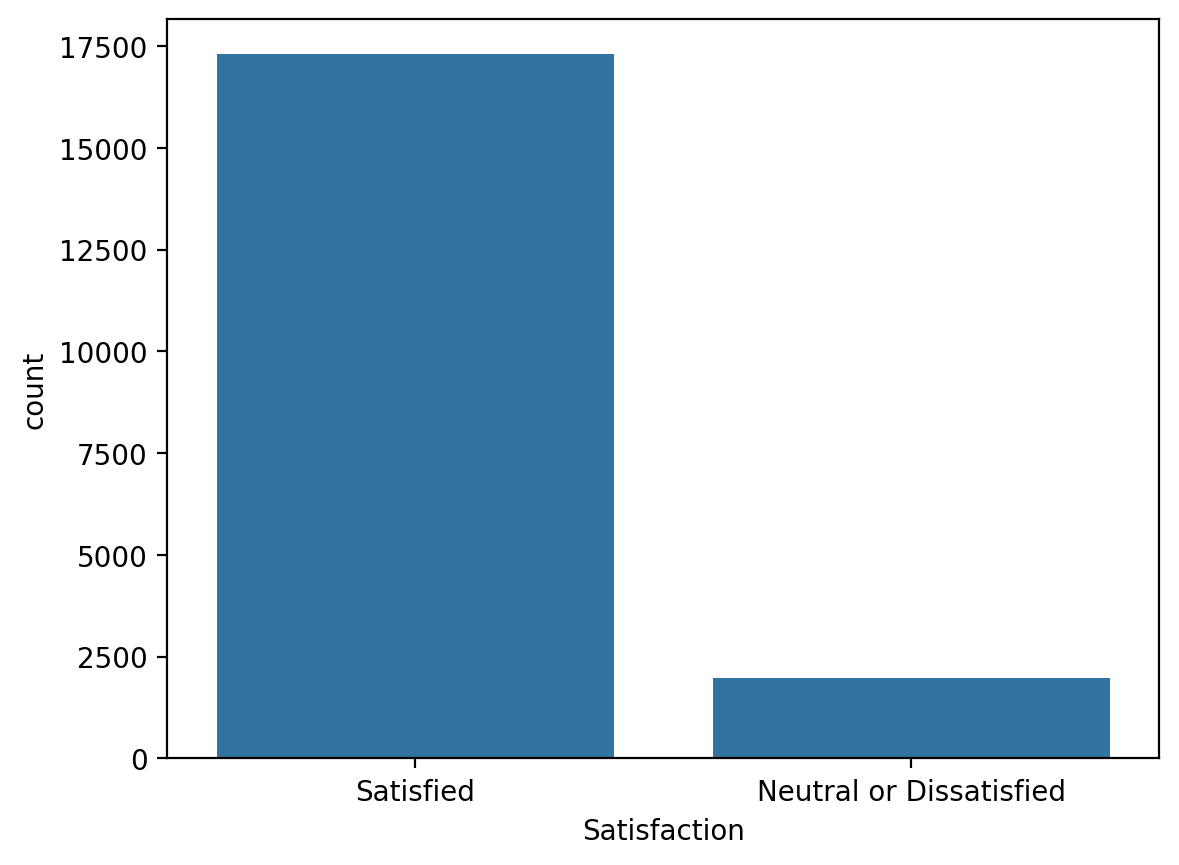

In [ ]:
#satisfaction의 카운트
sns.countplot(x='Satisfaction', data=data)
plt.show()

### (3) 결측치 확인

- 결측치 비율을 기준으로 내림차순 정렬해 확인합니다.

In [ ]:
#결측치의 비율을 내림차순으로 정리/ 위의 5개의 값이 결측가 있는것을발견
data.isnull().mean().sort_values(ascending=False)

,0
Age,0.033821
Inflight wifi service,0.033095
Seat comfort,0.025262
Food and drink,0.019971
Arrival Delay in Minutes,0.002801
Customer Type,0.000000
Unnamed: 0,0.000000
Gender,0.000000
ID,0.000000
Flight Distance,0.000000


In [ ]:
#결측치의 갯수
data.isnull().sum().sort_values(ascending=False)

,0
Age,652
Inflight wifi service,638
Seat comfort,487
Food and drink,385
Arrival Delay in Minutes,54
Customer Type,0
Unnamed: 0,0
Gender,0
ID,0
Flight Distance,0


### (4) 결측치 채우기

- 결측치가 있는 수치형 변수는 **중앙값**으로, 범주형 변수는 **최빈값**으로 채웁니다.
    - 수치형 변수: 'Age', 'Arrival Delay in Minutes'
    - 범주형 변수: 'Inflight wifi service', 'Seat comfort', 'Food and drink'
- 추천: 이후 확장성을 위해 범주형/수치형 변수를 자동 선택하고, 결측치를 일괄 처리합니다.

In [ ]:
# 수치형 변수 선택
num_cols = data.select_dtypes(include=['number']).columns

# 결측치 → 중앙값
for col in num_cols:
    data[col].fillna(data[col].median(), inplace=True)

In [ ]:
# 범주형 변수 선택
cat_cols = data.select_dtypes(include=['object']).columns

# 결측치 → 최빈값
for col in cat_cols:
    data[col].fillna(data[col].mode()[0], inplace=True)

### (5) Target 값 변경

- Target인 **Satisfaction** 변수  값을 1과 0으로 변경합니다.
    - 'Satisfied'--> 1,
    - 'Neutral or Dissatisfied' --> 0
- **map()** 메서드를 사용합니다.

In [ ]:
#map을 이용하여 Satisfied는 1, Neutral or Dissatisfied는 0으로 설정
data['Satisfaction'] = data['Satisfaction'].map({'Satisfied': 1, 'Neutral or Dissatisfied': 0})

### (6) 불필요한 변수 제거

- 다음 변수는 분석에 의미가 없으므로 제거합니다.
    - 'Unnamed: 0'
    - 'ID'

In [ ]:
#id와 unnamed: 0은 필요가 없기에 삭제
data.drop(columns=['Unnamed: 0', 'ID'], inplace=True)

## **3. 미션 2: 가설 수립과 검증**

### (1) 가설 수립

- 'ㅇㅇ이면 ㅇㅇ일 것이다' 라는 형식의 가설을 5개 이상 세워봅니다.
- 이후 분석 과정을 통해 수립한 가설을 검증합니다.
- 특히 이변량 분석을 통해 가설을 검증하도록 합니다.

In [ ]:
# 가설 1 : 도착 지연 시간이 길수록 만족도는 낮을 것이다.
# 가설 2 : 청결도가 높을수록 만족도는 높을 것이다
# 가설 3 : 비행 거리가 길수록 만족도는 낮을 것이다
# 가설 4 : 기내식 만족도가 높을수록 만족도는 높을 것이다.
# 가설 5 : 와이파이 서비스가 좋을수록 만족도는 높을 것이다.

### (2) 단변량 분석

- 5개 이상의 변수에 대한 단변량 분석을 수행합니다.
- 각 분석에 대한 의견을 주석으로 정리합니다.

In [ ]:
data['Arrival Delay in Minutes'].describe()
#분포로 보았을때는 잘 나오지않아 확인할수가없다

,Arrival Delay in Minutes
count,19278.000000
mean,12.797697
std,34.490208
min,0.000000
25%,0.000000
50%,0.000000
75%,9.000000
max,920.000000


In [ ]:
(data['Arrival Delay in Minutes'] == 0).value_counts()
# 의견: 도착 시간이 지연되었는지 안되었는지 참거짓으로 표현함. 참: 지연 없음, 거짓 : 지연됨

,count
Arrival Delay in Minutes,
True,11620
False,7658


In [ ]:
data['Cleanliness'].value_counts()
# 의견:  보통 4점이 제일 많이 분포되어있는 것을 볼수있다.

,count
Cleanliness,
4,6073
5,5552
3,4542
2,1730
1,1381


In [ ]:
data['Flight Distance'].describe()
#의견 : 중간값은 1119km로 최대 5천키로미터에서 최소 56키로미터로 다양하게 분포되어있다

,Flight Distance
count,19278.000000
mean,1474.563544
std,1117.574556
min,56.000000
25%,495.000000
50%,1119.000000
75%,2321.000000
max,4983.000000


In [ ]:
data['Food and drink'].value_counts()
#의견 : 기내식 평점도 4점이 제일 많은걸 알수있다

,count
Food and drink,
4.0,5642
5.0,4853
3.0,3723
2.0,3708
1.0,1333
0.0,19


In [ ]:
data['Inflight wifi service'].value_counts()
#의견 : 와이파이 또한 4점이 제일 많다

,count
Inflight wifi service,
4.0,4712
5.0,4192
3.0,3750
2.0,3022
1.0,2494
0.0,1108


### (3) 이변량 분석

- 5개 이상의 이변량 분석을 수행합니다.
- 각 분석에 대한 의견을 주석으로 정리합니다.

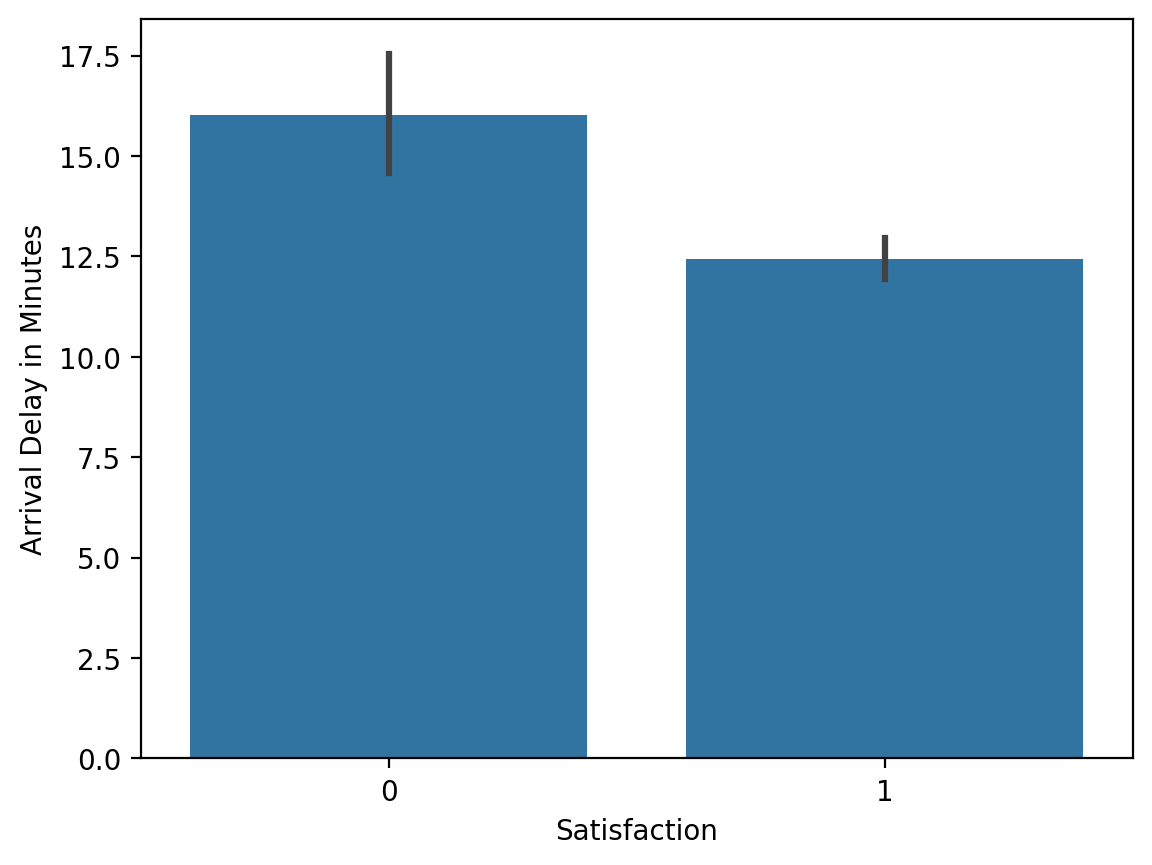

In [ ]:
sns.barplot(x='Satisfaction', y='Arrival Delay in Minutes', data=data)
plt.show()

# 의견:불만족이 더 높은것을 알수있다

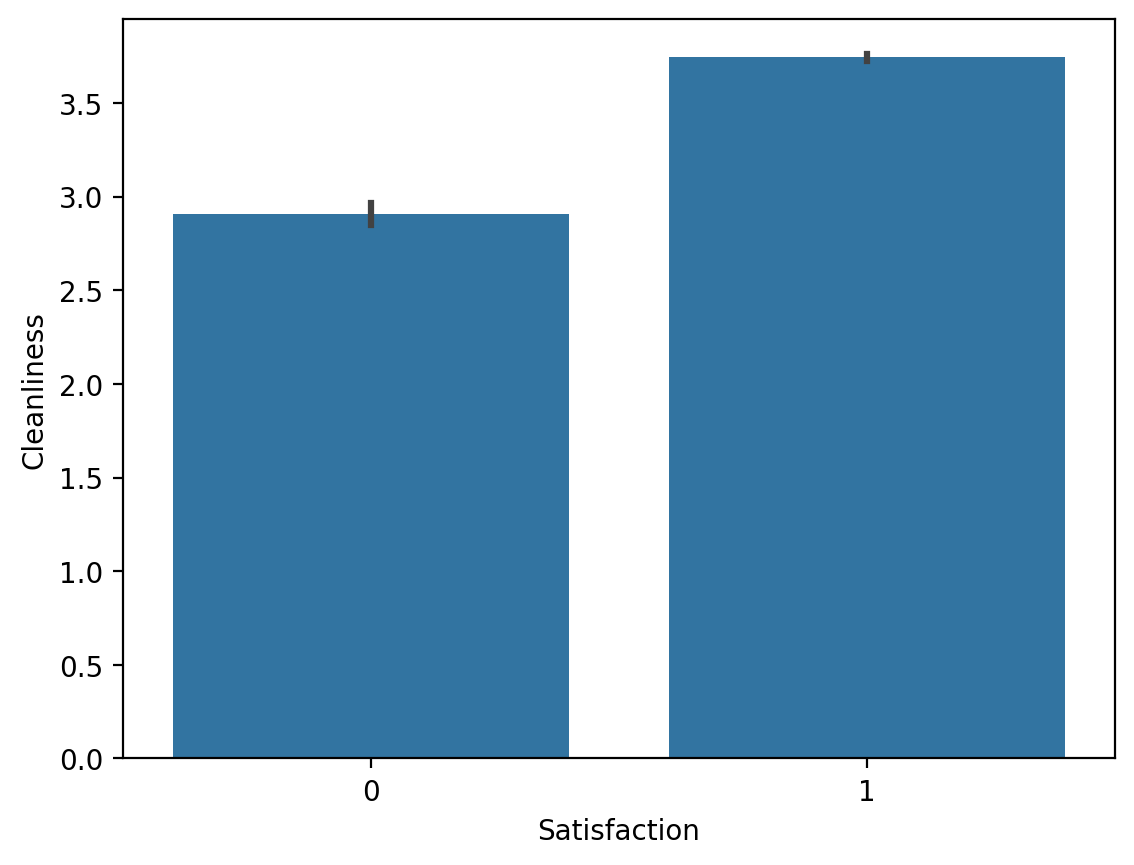

In [ ]:
sns.barplot(x='Satisfaction', y='Cleanliness', data=data)
plt.show()

# 의견: 청결도가 높을수록 만족도도 높은것을 볼수있다

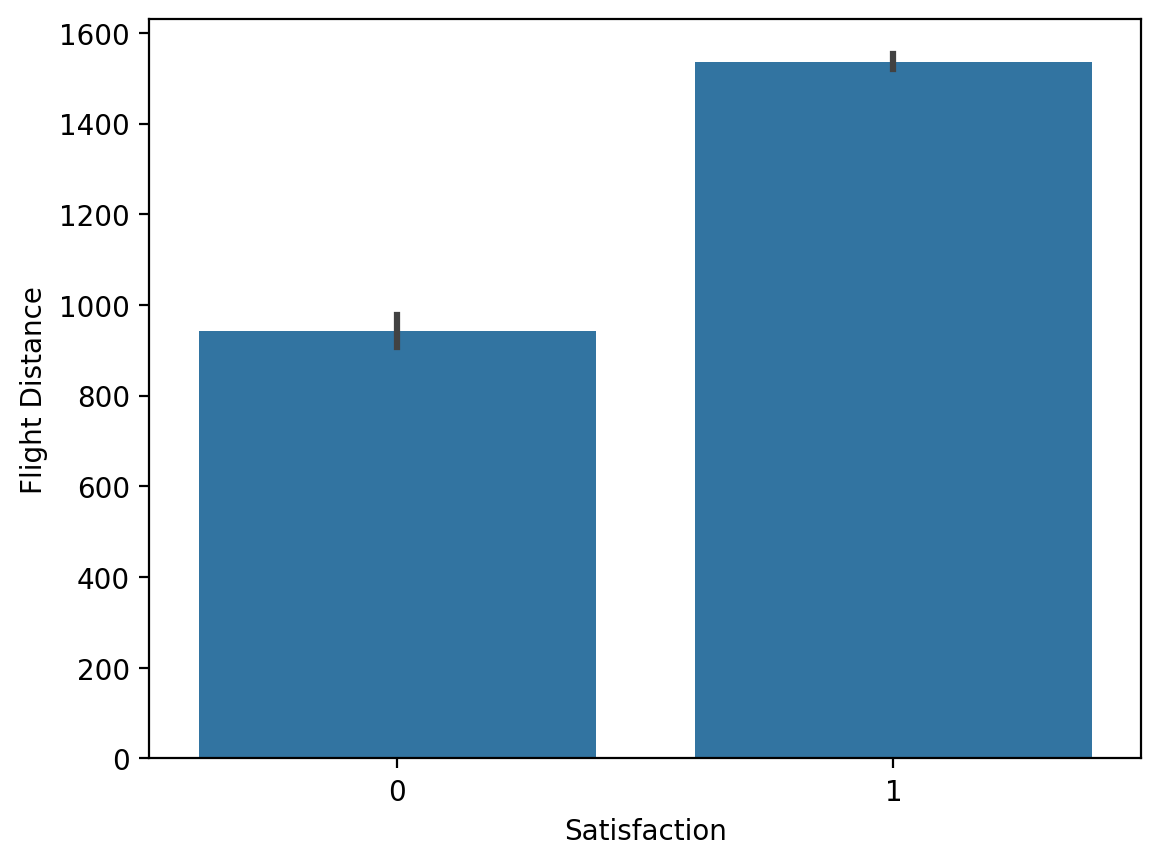

In [ ]:
sns.barplot(x='Satisfaction', y='Flight Distance', data=data)
plt.show()

# 의견: 비행거리가 길수록 만족도가 높게 나온다

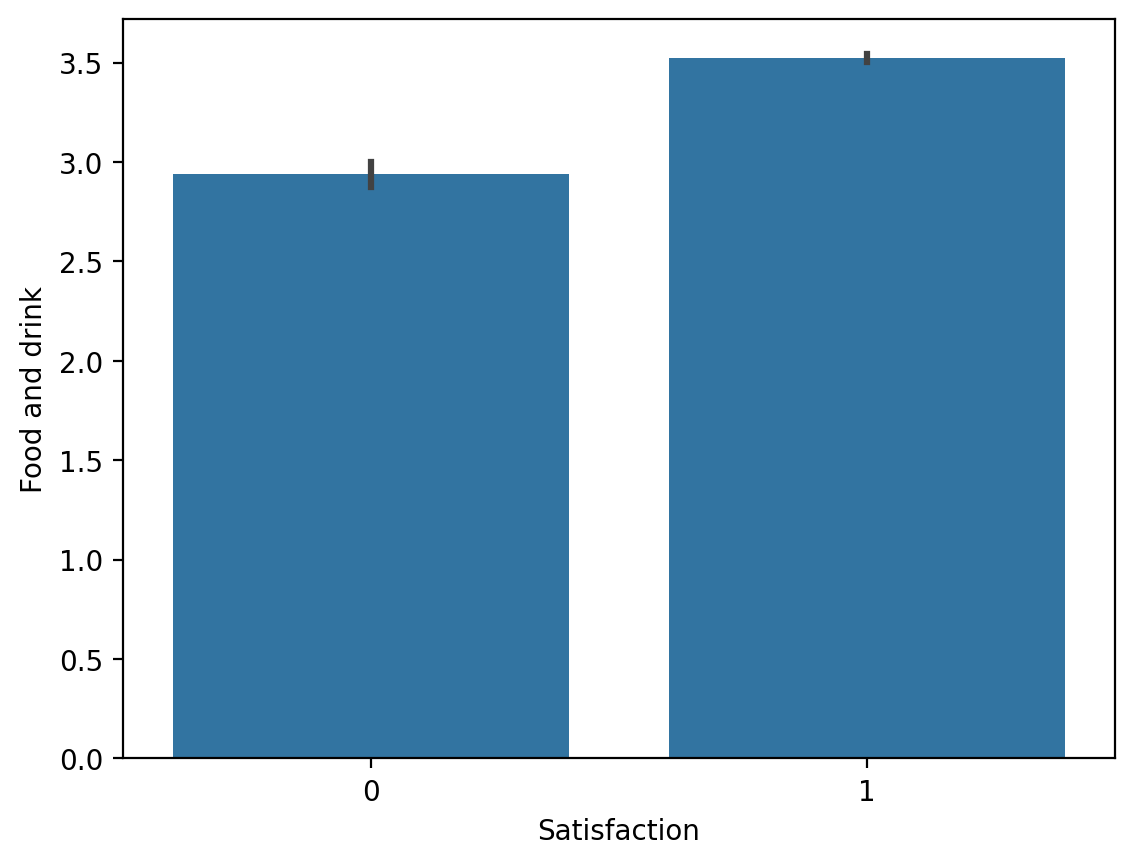

In [ ]:
sns.barplot(x='Satisfaction', y='Food and drink', data=data)
plt.show()

# 의견: 음식 만족도가 높을수록 만족도가 높게 나오는걸 볼수있다

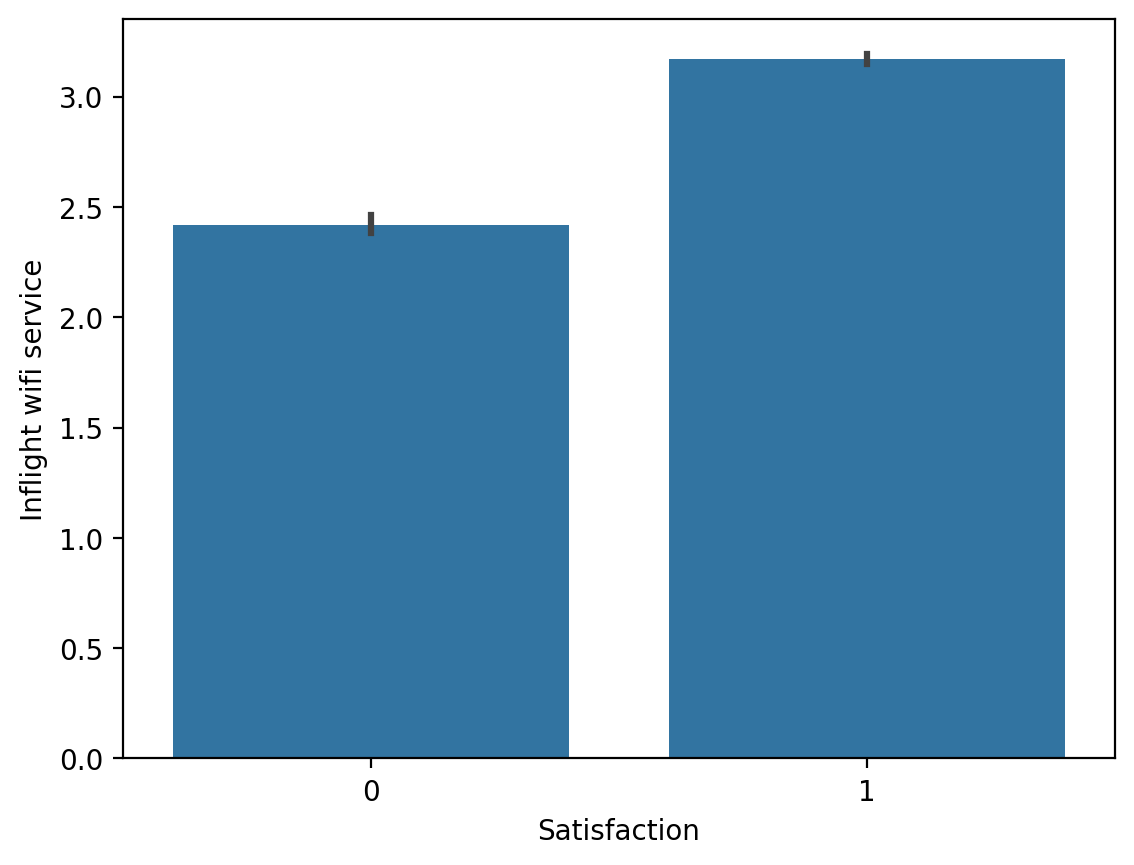

In [ ]:
sns.barplot(x='Satisfaction', y='Inflight wifi service', data=data)
plt.show()

# 의견: 여기도 마찬가지로 와이파이 서비스가 좋을수록 만족도가 더 높게 나온다

## **4. 미션 3: 머신러닝 모델링 #1**

- Tree 기반 알고리즘을 사용해야 **변수 중요도**를 확인할 수 있습니다.
- **RandomForest** 알고리즘을 사용해 머신러닝 모델을 만들고 성능을 평가합니다.
- **변수 중요도**를 확인해 추가 분석 대상 변수를 선정합니다.

### (1) 전처리

- 최소한 문자열 데이터가 없어야 하고, 결측치도 없도록 전처리해야 합니다.
- 결측치는 이전 단계에서 처리한 상태입니다.
- 범주형 변수에 대해 **LabelEncoder**를 사용해 인코딩합니다.
- 변수 중요도를 확인하기 위함이므로 가변수화를 하지 않습니다.

In [ ]:
# 변수 확인
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19278 entries, 0 to 19277
Data columns (total 23 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Gender                             19278 non-null  object 
 1   Customer Type                      19278 non-null  object 
 2   Age                                19278 non-null  float64
 3   Type of Travel                     19278 non-null  object 
 4   Class                              19278 non-null  object 
 5   Flight Distance                    19278 non-null  int64  
 6   Inflight wifi service              19278 non-null  float64
 7   Departure/Arrival time convenient  19278 non-null  int64  
 8   Ease of Online booking             19278 non-null  int64  
 9   Gate location                      19278 non-null  int64  
 10  Food and drink                     19278 non-null  float64
 11  Online boarding                    19278 non-null  int

In [ ]:
# 문자열 변수 리스트로 선언
cat_cols = data.select_dtypes(include='object').columns

# 라벨 인코딩
for col in cat_cols:
    encoder = LabelEncoder()
    data[col] = encoder.fit_transform(data[col])

- info() 메서드로 변수 정보를 다시 확인합니다.
- **Dtype에 object 형식의 열이 있으면 이후 과정을 진행할 수 없습니다.**

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19278 entries, 0 to 19277
Data columns (total 23 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Gender                             19278 non-null  int64  
 1   Customer Type                      19278 non-null  int64  
 2   Age                                19278 non-null  float64
 3   Type of Travel                     19278 non-null  int64  
 4   Class                              19278 non-null  int64  
 5   Flight Distance                    19278 non-null  int64  
 6   Inflight wifi service              19278 non-null  float64
 7   Departure/Arrival time convenient  19278 non-null  int64  
 8   Ease of Online booking             19278 non-null  int64  
 9   Gate location                      19278 non-null  int64  
 10  Food and drink                     19278 non-null  float64
 11  Online boarding                    19278 non-null  int

- target 변수를 선정하고 x, y를 분리합니다.

In [ ]:
# x, y 분리
target = 'Satisfaction'

x = data.drop(target, axis=1)
y = data.loc[:, target]

- 학습용, 검증용 데이터를 7:3으로 분리합니다.

In [ ]:
## 학습용, 검증용 분리
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.3, random_state=1, stratify=y)

### (2) 모델링

- 머신러닝 모델링을 수행합니다.
- 검증 데이터로 예측하고 성능을 평가해 봅니다.

In [ ]:
#선언하기
model = RandomForestClassifier()

In [ ]:
#학습하기
model.fit(x_train, y_train)

RandomForestClassifier()

In [ ]:
#예측하기
y_pred = model.predict(x_val)

In [ ]:
#평가하기
print(confusion_matrix(y_val, y_pred))
print('-'*60)
print(classification_report(y_val, y_pred))
print('-'*60)
print("Accuracy:", accuracy_score(y_val, y_pred))

[[ 449  147]
 [  56 5132]]
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.89      0.75      0.82       596
           1       0.97      0.99      0.98      5188

    accuracy                           0.96      5784
   macro avg       0.93      0.87      0.90      5784
weighted avg       0.96      0.96      0.96      5784

------------------------------------------------------------
Accuracy: 0.9649031811894883


### (3) 변수 중요도 확인

- 변수 중요도를 시각화해 확인합니다.

In [ ]:
#중요변수를 가져온다
imp = model.feature_importances_

#가져온 중요도를 데이터프레임으로 만들어서 중요도를 내림차순으로 정리
importance = pd.DataFrame({'Feature': x_train.columns,
                           'Importance': imp}).sort_values(by='Importance', ascending=False)

In [ ]:
importance

,Feature,Importance
6,Inflight wifi service,0.144887
11,Online boarding,0.122858
3,Type of Travel,0.090625
8,Ease of Online booking,0.086745
4,Class,0.055966
2,Age,0.050273
13,Inflight entertainment,0.047816
5,Flight Distance,0.046895
15,Leg room service,0.039457
12,Seat comfort,0.033681


### (4) 결과 정리

- 가장 중요하다고 확인된 변수 5개는 무엇인가요?


In [ ]:
# 1. Inflight wifi service
# 2. Online boarding
# 3. Type of Travel
# 4. Ease of Online booking
# 5. Class

- 가장 중요하지 않다고 확인된 변수 5개는 무엇인가요?

In [ ]:
# 1. Gender
# 2. Food and drink
# 3. Gate location
# 4. Departure Delay in Minutes
# 5. Departure/Arrival time convenient

## **5. 미션 4: 머신러닝 모델링 #2**

- 35세를 기준으로 데이터를 분리해 각각에 대한 모델을 만들어봅니다.

### (1) 데이터 분리

- 더 세분화할 수 있지만, 35세를 기준으로 두 개의 데이터프레임을 만듭니다.
    - **data01**: Age <= 35
    - **data02**: Age > 35

In [ ]:
# 데이터 분리
data01 = data[data['Age'] <= 35]
data02 = data[data['Age'] > 35]

### (2) 35세 이하 모델링

- **data01** 데이터프레임을 대상으로 모델링을 수행합니다.
- 우선 target 변수를 선정하고 x, y를 분리합니다.

In [ ]:
# x, y 분리
target = 'Satisfaction'

x = data01.drop(target, axis=1)
y = data01.loc[:, target]

- 학습용, 검증용 데이터를 7:3으로 분리합니다.

In [ ]:
## 학습용, 검증용 분리
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.3, random_state=1, stratify=y)

- 모델링을 수행합니다.

In [ ]:
#선언하기
model = RandomForestClassifier()

In [ ]:
#학습하기
model.fit(x_train, y_train)

RandomForestClassifier()

In [ ]:
#예측하기
y_pred = model.predict(x_val)

In [ ]:
#평가하기
print(confusion_matrix(y_val, y_pred))
print('-'*60)
print(classification_report(y_val, y_pred))
print('-'*60)
print("Accuracy:", accuracy_score(y_val, y_pred))

[[ 228   46]
 [  17 1458]]
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.93      0.83      0.88       274
           1       0.97      0.99      0.98      1475

    accuracy                           0.96      1749
   macro avg       0.95      0.91      0.93      1749
weighted avg       0.96      0.96      0.96      1749

------------------------------------------------------------
Accuracy: 0.9639794168096055


- 변수 중요도를 확인합니다.

In [ ]:
#중요변수를 가져온다
imp = model.feature_importances_

#가져온 중요도를 데이터프레임으로 만들어서 중요도를 내림차순으로 정리
importance = pd.DataFrame({'Feature': x_train.columns, 'Importance': imp}).sort_values(by='Importance', ascending=False)
importance

,Feature,Importance
11,Online boarding,0.182418
6,Inflight wifi service,0.174818
8,Ease of Online booking,0.089522
3,Type of Travel,0.069033
4,Class,0.059356
5,Flight Distance,0.051469
2,Age,0.041095
21,Arrival Delay in Minutes,0.028505
14,On-board service,0.028460
13,Inflight entertainment,0.026336


- 중요하다고 확인된 변수 5개는 무엇인가요?


In [ ]:
# 1. Online boarding
# 2. Inflight wifi service
# 3. Ease of Online booking
# 4. Type of Travel
# 5. Class

- 중요하지 않다고 확인된 변수 5개는 무엇인가요?

In [ ]:
# 1. Food and drink
# 2. Leg room service
# 3. Seat comfort
# 4. Cleanliness
# 5. Gender

### (3) 35세 초과 모델링

- **data02** 데이터프레임을 대상으로 모델링을 수행합니다.
- 우선 target 변수를 선정하고 x, y를 분리합니다.

In [ ]:
# x, y 분리
target = 'Satisfaction'

x = data02.drop(target, axis=1)
y = data02.loc[:, target]

- 학습용, 검증용 데이터를 7:3으로 분리합니다.

In [ ]:
## 학습용, 검증용 분리
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.3, random_state=1, stratify=y)

- 모델링을 수행합니다.

In [ ]:
#선언하기
model = RandomForestClassifier()

#학습하기
model.fit(x_train, y_train)

RandomForestClassifier()

In [ ]:
#예측하기
y_pred = model.predict(x_val)

In [ ]:
#평가하기
print(confusion_matrix(y_val, y_pred))
print('-'*60)
print(classification_report(y_val, y_pred))
print('-'*60)
print("Accuracy:", accuracy_score(y_val, y_pred))

[[ 242   79]
 [  43 3671]]
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.85      0.75      0.80       321
           1       0.98      0.99      0.98      3714

    accuracy                           0.97      4035
   macro avg       0.91      0.87      0.89      4035
weighted avg       0.97      0.97      0.97      4035

------------------------------------------------------------
Accuracy: 0.9697645600991326


- 변수 중요도를 확인합니다.

In [ ]:
#중요변수를 가져온다
imp = model.feature_importances_

#가져온 중요도를 데이터프레임으로 만들어서 중요도를 내림차순으로 정리
importance = pd.DataFrame({'Feature': x_train.columns, 'Importance': imp}).sort_values(by='Importance', ascending=False)
importance

,Feature,Importance
6,Inflight wifi service,0.138027
3,Type of Travel,0.092852
11,Online boarding,0.087229
8,Ease of Online booking,0.070183
15,Leg room service,0.070152
4,Class,0.054698
5,Flight Distance,0.051800
13,Inflight entertainment,0.046920
2,Age,0.045490
12,Seat comfort,0.041544


- 가장 중요하다고 확인된 변수 5개는 무엇인가요?


In [ ]:
# 1. Inflight wifi service
# 2. Type of Travel
# 3. Online boarding
# 4. Ease of Online booking
# 5. Leg room service

- 가장 중요하지 않다고 확인된 변수 5개는 무엇인가요?

In [ ]:
# 1. Inflight service
# 2. Customer Type
# 3. Food and drink
# 4. Gate location
# 5. Gender

### (4) 의견 정리

- 위 모델링 과정과 변수 중요도 확인 과정 결과에 대한 의견을 정리합니다.

In [ ]:
# 35세 이하와 35세 이상의 변수 중요도 결과를 보면 확실히 다른 결과가 나왔습니다
# 나이에 따라서 선호하는 것들이 달라 큰차이를 만든 것으로 보입니다
# 그리고 서비스와 관련된 변수들이 만족도 큰 영향을 미치는 것으로 보여지고 있습니다
# 특히 와이파이, 온라인예약, 그리고 예약이 편함도가 가장 큰 영향력을 볼 수 있습니다.

## **6. 미션 5: 데이터 분석**

- 위에서 확인된 변수 중요도를 기준으로 분석할 변수를 5개 선정하고 분석을 수행합니다.
- **data** 데이터프레임을 대상으로 분석합니다.
- Satisfaction 변수와의 **이변량 분석**에 중점을 두고 수행합니다.
- 각 분석 결과에 대한 의견을 주석으로 정리합니다.

In [ ]:
#제일 영향력이 높은 와이파이를 가져왔습니다. 확실히 와이파이와 만족도에 영향을 주고 있습니
data.groupby('Satisfaction')['Inflight wifi service'].mean()

,Inflight wifi service
Satisfaction,
0,2.419647
1,3.168507


In [ ]:
#그다음 온라인예약으로 확인해보았습니다
data.groupby('Satisfaction')['Online boarding'].mean()

,Online boarding
Satisfaction,
0,2.661461
1,4.028740


In [ ]:
#그다음 가장 영향력이 없는 gender으로 확인해보았습니다
data.groupby('Satisfaction')['Gender'].mean()

,Gender
Satisfaction,
0,0.500756
1,0.502284


In [ ]:
#처음 가설을 정했던 도착 지연 시간를 가져왔습니다
data.groupby('Satisfaction')['Arrival Delay in Minutes'].mean()

,Arrival Delay in Minutes
Satisfaction,
0,16.008564
1,12.429133


In [ ]:
#그후 마지막으로 중간에 있는 값이 checkin service를 가져왔습니다
data.groupby('Satisfaction')['Checkin service'].mean()

,Checkin service
Satisfaction,
0,3.048866
1,3.650899


## **7. 저장하기**

- **to_csv()** 메서드를 사용해 이후 과정을 위해 data 데이터프레임을 **project01** 폴더에 저장합니다.
    - index=False 옵션 지정
    - data → path + 'data.csv'
    
- 저장된 파일을 필히 확인합니다.

In [ ]:
# 파일 저장
data.to_csv(path + 'data.csv', index=False)